In [ ]:
PRESET = "fast"        # fast (15 min)
DATA_SOURCE = "drive"
DRIVE_PATH = "/content/drive/MyDrive/waveguide_colab_256.npz"
DATA_URL = ""

PRESETS = {
    "smoke": dict(folds=2, epochs=6,  seeds=1, y_folds=2, y_epochs=6),
    "fast":  dict(folds=5, epochs=40, seeds=1, y_folds=3, y_epochs=30),
    "full":  dict(folds=5, epochs=60, seeds=1, y_folds=5, y_epochs=60),
}
CFG = PRESETS[PRESET]

BATCH_SIZE = 64
LEARNING_RATE = 8e-4
WEIGHT_DECAY = 2e-4
DROPOUT = 0.10
WARMUP_EPOCHS = 5
GRADIENT_CLIP = 1.0
VALIDATION_EVERY = 2      # epochs between held-out loss evaluations

X_SIGMA_UM = 1.5          # target width, about 3 x-sample spacings
Y_SIGMA_UM = 0.05
W_X_DISTRIBUTION, W_X_EXPECTATION, W_SHAPE, W_Y = 1.0, 0.5, 0.5, 0.3

ORDER = ["mlp", "cnn", "transformer", "gru", "ntm"]
print(f"preset {PRESET}: {CFG}")

preset fast: {'folds': 5, 'epochs': 40, 'seeds': 1, 'y_folds': 3, 'y_epochs': 30}


In [ ]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}   device {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  {torch.cuda.get_device_name(0)}")
else:
    print("  WARNING: no GPU. Runtime > Change runtime type > T4 GPU.")

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.edgecolor": "#c3c2b7", "legend.frameon": False,
})
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
SHAPE_STYLE = {"circle": (BLUE, "o"), "ellipse": (ORANGE, "D"),
               "square": (AQUA, "s"), "triangle": (VIOLET, "^")}

torch 2.11.0+cu128   device cuda
  NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
def fetch_data_path() -> Path:
    if DATA_SOURCE == "drive":
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)
        return Path(DRIVE_PATH)

    if DATA_SOURCE == "upload":
        from google.colab import files

        uploaded = files.upload()
        return Path(next(iter(uploaded)))

    if DATA_SOURCE == "url":
        import urllib.request

        target = Path("/content/waveguide_colab.npz")
        if not target.exists():
            urllib.request.urlretrieve(DATA_URL, target)
        return target

    raise ValueError(f"unknown DATA_SOURCE {DATA_SOURCE!r}")


def load_pack(path: Path) -> dict:
    """Read the tensor pack, from a bare .npz or from inside a .zip."""
    if path.suffix.lower() == ".zip":
        with zipfile.ZipFile(path) as archive:
            inner = [n for n in archive.namelist() if n.endswith(".npz")]
            if not inner:
                raise FileNotFoundError(f"no .npz inside {path.name}")
            print(f"reading {inner[0]} from {path.name}")
            with archive.open(inner[0]) as handle:
                with np.load(handle, allow_pickle=False) as pack:
                    return {key: pack[key] for key in pack.files}
    with np.load(path, allow_pickle=False) as pack:
        return {key: pack[key] for key in pack.files}


pack = load_pack(fetch_data_path())
NF, FF = pack["nf"], pack["ff"]
X_TRUE, Y_TRUE = pack["x_um"], pack["y_um"]
SHAPE_ID = pack["shape_id"]
SOURCE, SWEEP_GROUP = pack["source"], pack["sweep_group"]
SHAPE_NAMES = [str(s) for s in pack["shape_names"]]
CHANNELS = [str(c) for c in pack["channel_names"]]
META = json.loads(str(pack["meta"].item()))

IN_CHANNELS, N_POINTS = NF.shape[1], NF.shape[2]
print(f"\n{len(X_TRUE)} rows   {IN_CHANNELS} channels x {N_POINTS} points "
      f"per domain")
print(f"shapes {SHAPE_NAMES}")
for index, name in enumerate(SHAPE_NAMES):
    print(f"   {name:9s} {int((SHAPE_ID == index).sum())}")
print(f"x-sweep rows {int((SOURCE == 'x_sweep').sum())}   "
      f"y-sweep rows {int((SOURCE == 'y_sweep').sum())}")
print(f"y levels: {len(np.unique(Y_TRUE[SOURCE == 'y_sweep']))}")

Mounted at /content/drive

3152 rows   42 channels x 256 points per domain
shapes ['circle', 'ellipse', 'square', 'triangle']
   circle    788
   ellipse   788
   square    788
   triangle  788
x-sweep rows 1152   y-sweep rows 2000
y levels: 20


In [ ]:
def blocked_x_folds(x, n_folds, buffer_um=1.5, group=None):
    x = np.asarray(x, dtype=np.float64)
    keys = np.zeros(len(x), np.int64) if group is None else np.asarray(group)
    block = np.full(len(x), -1, np.int64)
    for key in np.unique(keys):
        member = np.flatnonzero(keys == key)
        positions = np.unique(x[member])
        for index, part in enumerate(np.array_split(positions, n_folds)):
            block[member[np.isin(x[member], part)]] = index

    folds = []
    everything = np.arange(len(x), dtype=np.int64)
    for index in range(n_folds):
        test = everything[block == index]
        candidate = everything[block != index]
        low, high = x[test].min(), x[test].max()
        close = (x[candidate] >= low - buffer_um) & (x[candidate] <= high + buffer_um)
        folds.append({
            "id": index, "train": candidate[~close], "test": test,
            "regime": "extrapolation" if index in (0, n_folds - 1)
                      else "interpolation",
        })
    return folds


def grouped_sweep_folds(groups, n_folds, seed=2026, stratify=None):
    groups = np.asarray(groups)
    strata = np.zeros(len(groups)) if stratify is None else np.asarray(stratify)
    assignment = np.zeros(len(groups), np.int64)
    for stratum in np.unique(strata):
        unique = np.unique(groups[strata == stratum])
        rng = np.random.default_rng(seed + abs(hash(str(stratum))) % 9999)
        shuffled = unique.copy()
        rng.shuffle(shuffled)
        for index, part in enumerate(np.array_split(shuffled, n_folds)):
            assignment[np.isin(groups, part)] = index
    everything = np.arange(len(groups), dtype=np.int64)
    return [{"id": i, "train": everything[assignment != i],
             "test": everything[assignment == i], "regime": "interpolation"}
            for i in range(n_folds)]


def audit(folds, n_rows):
    tested = np.zeros(n_rows, np.int64)
    for fold in folds:
        assert not np.intersect1d(fold["train"], fold["test"]).size, "overlap"
        tested[fold["test"]] += 1
    assert np.all(tested == 1), "every row must be tested exactly once"


X_ROWS = np.flatnonzero(SOURCE == "x_sweep")
SHAPE_LABEL = np.asarray(SHAPE_NAMES)[SHAPE_ID]
x_folds = blocked_x_folds(X_TRUE[X_ROWS], CFG["folds"],
                          group=SHAPE_LABEL[X_ROWS])
audit(x_folds, len(X_ROWS))
print(f"{CFG['folds']} blocked folds over {len(X_ROWS)} x-sweep rows — "
      "leakage audit passed")
for fold in x_folds:
    span = X_TRUE[X_ROWS][fold["test"]]
    print(f"  fold {fold['id']} {fold['regime']:13s} "
          f"train {len(fold['train']):4d}  test {len(fold['test']):4d}  "
          f"x {span.min():7.2f} .. {span.max():7.2f}")

5 blocked folds over 1152 x-sweep rows — leakage audit passed
  fold 0 extrapolation train  876  test  240  x  -48.00 ..  -38.79
  fold 1 interpolation train  852  test  228  x  -38.30 ..  -29.58
  fold 2 interpolation train  852  test  228  x  -29.09 ..  -20.36
  fold 3 interpolation train  852  test  228  x  -19.88 ..  -11.15
  fold 4 extrapolation train  888  test  228  x  -10.67 ..   -1.94


### 1. MLP

In [ ]:
class MLPEncoder(nn.Module):
    def __init__(self, in_channels, n_points, widths=(512, 256, 128),
                 pre_pool=64, dropout=DROPOUT):
        super().__init__()
        self.pre_pool = pre_pool
        layers, previous = [nn.Flatten()], in_channels * (pre_pool or n_points)
        for width in widths:
            layers += [nn.Linear(previous, width), nn.LayerNorm(width),
                       nn.LeakyReLU(0.01), nn.Dropout(dropout)]
            previous = width
        self.network = nn.Sequential(*layers)
        self.output_size = previous

    def forward(self, values):
        if self.pre_pool:
            values = F.adaptive_avg_pool1d(values, self.pre_pool)
        return self.network(values)

### CNN
response wherever it occurred, for the shape head).

In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, in_channels, n_points, width=64, dropout=DROPOUT):
        super().__init__()
        half = width // 2
        self.network = nn.Sequential(
            nn.Conv1d(in_channels, half, 1), nn.GroupNorm(8, half),
            nn.LeakyReLU(0.01),
            nn.Conv1d(half, half, 7, padding=3), nn.GroupNorm(8, half),
            nn.LeakyReLU(0.01), nn.MaxPool1d(2),
            nn.Conv1d(half, width, 5, padding=2), nn.GroupNorm(8, width),
            nn.LeakyReLU(0.01), nn.MaxPool1d(2),
            nn.Conv1d(width, width, 3, padding=1), nn.GroupNorm(8, width),
            nn.LeakyReLU(0.01), nn.Dropout(dropout),
        )
        self.coarse_pool = nn.AdaptiveAvgPool1d(8)
        self.output_size = width * 8 + width

    def forward(self, values):
        features = self.network(values)
        return torch.cat([self.coarse_pool(features).flatten(1),
                          torch.amax(features, dim=-1)], dim=1)

### Transformer



In [ ]:
DEFAULT_TOKENS = 16


def resolve_patch(patch, n_points):
    patch = patch or max(n_points // DEFAULT_TOKENS, 1)
    assert n_points % patch == 0, f"patch {patch} must divide {n_points}"
    return patch


class TransformerEncoder1D(nn.Module):
    def __init__(self, in_channels, n_points, patch=None, d_model=128,
                 n_heads=4, n_layers=4, feedforward=256, dropout=DROPOUT):
        super().__init__()
        patch = resolve_patch(patch, n_points)
        n_tokens = n_points // patch
        self.tokenizer = nn.Conv1d(in_channels, d_model, patch, stride=patch)
        self.class_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.position = nn.Parameter(torch.zeros(1, n_tokens + 1, d_model))
        nn.init.trunc_normal_(self.position, std=0.02)
        nn.init.trunc_normal_(self.class_token, std=0.02)
        layer = nn.TransformerEncoderLayer(
            d_model, n_heads, feedforward, dropout, activation="gelu",
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, n_layers,
                                             enable_nested_tensor=False)
        self.norm = nn.LayerNorm(d_model)
        self.output_size = 2 * d_model

    def forward(self, values):
        tokens = self.tokenizer(values).transpose(1, 2)
        tokens = torch.cat(
            [self.class_token.expand(tokens.size(0), -1, -1), tokens], 1)
        tokens = self.norm(self.encoder(tokens + self.position))
        return torch.cat([tokens[:, 0], tokens[:, 1:].mean(1)], dim=1)

### BiGRU


In [ ]:
class GRUEncoder(nn.Module):
    def __init__(self, in_channels, n_points, patch=None, token_width=64,
                 hidden=96, n_layers=2, dropout=DROPOUT):
        super().__init__()
        patch = resolve_patch(patch, n_points)
        self.tokenizer = nn.Sequential(
            nn.Conv1d(in_channels, token_width, patch, stride=patch),
            nn.GroupNorm(8, token_width), nn.SiLU())
        self.rnn = nn.GRU(token_width, hidden, n_layers, batch_first=True,
                          bidirectional=True,
                          dropout=dropout if n_layers > 1 else 0.0)
        self.output_size = 4 * hidden

    def forward(self, values):
        sequence, _ = self.rnn(self.tokenizer(values).transpose(1, 2))
        return torch.cat([sequence[:, -1], sequence.mean(1)], dim=1)

### 5. NTM

Graves, Wayne & Danihelka (arXiv:1410.5401) .

In [ ]:
def shift_index(n_slots, span, device):
    half = span // 2
    positions = torch.arange(n_slots, device=device)
    displacements = torch.arange(span, device=device) - half
    return (positions[None, :] - displacements[:, None]) % n_slots


class NTMHead(nn.Module):
    def __init__(self, controller_size, memory_width, shift_span=3,
                 is_write=False):
        super().__init__()
        self.shift_span, self.is_write = shift_span, is_write
        self.sizes = [memory_width, 1, 1, shift_span, 1]
        if is_write:
            self.sizes += [memory_width, memory_width]
        self.project = nn.Linear(controller_size, sum(self.sizes))
        nn.init.xavier_uniform_(self.project.weight, gain=1.4)
        nn.init.constant_(self.project.bias, 0.0)
        self.register_buffer("index", torch.empty(0, dtype=torch.long),
                             persistent=False)

    def forward(self, state, memory, previous):
        parts = torch.split(self.project(state), self.sizes, dim=1)
        key, beta, gate, shift, gamma = parts[:5]
        key, beta = torch.tanh(key), F.softplus(beta)
        gate, shift = torch.sigmoid(gate), F.softmax(shift, dim=1)
        gamma = 1.0 + F.softplus(gamma)

        similarity = F.cosine_similarity(memory + 1e-16,
                                         key.unsqueeze(1) + 1e-16, dim=-1)
        gated = gate * F.softmax(beta * similarity, dim=1) + (1 - gate) * previous
        if self.index.numel() != memory.size(1) * self.shift_span:
            self.index = shift_index(memory.size(1), self.shift_span,
                                     memory.device)
        shifted = (shift.unsqueeze(-1) * gated[:, self.index]).sum(1)
        sharp = shifted.clamp_min(1e-16) ** gamma
        weights = sharp / sharp.sum(1, keepdim=True).clamp_min(1e-16)
        if not self.is_write:
            return weights, None, None
        return weights, torch.sigmoid(parts[5]), torch.tanh(parts[6])


class NTMEncoder(nn.Module):
    def __init__(self, in_channels, n_points, patch=None, token_width=64,
                 controller_size=128, memory_slots=64, memory_width=32,
                 dropout=DROPOUT):
        super().__init__()
        patch = resolve_patch(patch, n_points)
        self.tokenizer = nn.Sequential(
            nn.Conv1d(in_channels, token_width, patch, stride=patch),
            nn.GroupNorm(8, token_width), nn.SiLU())
        self.controller = nn.LSTMCell(token_width + memory_width,
                                      controller_size)
        self.read_head = NTMHead(controller_size, memory_width)
        self.write_head = NTMHead(controller_size, memory_width, is_write=True)
        self.initial_memory = nn.Parameter(
            torch.randn(memory_slots, memory_width) * 0.05)
        self.initial_read = nn.Parameter(torch.randn(memory_width) * 0.05)
        self.initial_read_address = nn.Parameter(torch.zeros(memory_slots))
        self.initial_write_address = nn.Parameter(torch.zeros(memory_slots))
        self.controller_size, self.memory_width = controller_size, memory_width
        self.dropout = nn.Dropout(dropout)
        self.output_size = 2 * (controller_size + memory_width)

    def forward(self, values):
        tokens = self.tokenizer(values).transpose(1, 2)
        batch, dtype, device = tokens.size(0), tokens.dtype, tokens.device
        memory = self.initial_memory.unsqueeze(0).expand(batch, -1, -1).to(dtype)
        read = self.initial_read.unsqueeze(0).expand(batch, -1).to(dtype)
        read_address = F.softmax(self.initial_read_address, 0).unsqueeze(0) \
            .expand(batch, -1).to(dtype)
        write_address = F.softmax(self.initial_write_address, 0).unsqueeze(0) \
            .expand(batch, -1).to(dtype)
        hidden = torch.zeros(batch, self.controller_size, device=device, dtype=dtype)
        cell = torch.zeros_like(hidden)

        outputs = []
        for step in range(tokens.size(1)):
            hidden, cell = self.controller(
                torch.cat([tokens[:, step], read], dim=1), (hidden, cell))
            write_address, erase, add = self.write_head(hidden, memory,
                                                        write_address)
            memory = memory * (1 - write_address.unsqueeze(-1) * erase.unsqueeze(1))
            memory = memory + write_address.unsqueeze(-1) * add.unsqueeze(1)
            read_address, _, _ = self.read_head(hidden, memory, read_address)
            read = torch.bmm(read_address.unsqueeze(1), memory).squeeze(1)
            outputs.append(torch.cat([hidden, read], dim=1))

        stacked = torch.stack(outputs, dim=1)
        return self.dropout(
            torch.cat([stacked[:, -1], stacked.mean(1)], dim=1))


ENCODERS = {"mlp": MLPEncoder, "cnn": CNNEncoder,
            "transformer": TransformerEncoder1D, "gru": GRUEncoder,
            "ntm": NTMEncoder}

In [ ]:
X_GRID = np.arange(np.floor(X_TRUE.min()), np.ceil(X_TRUE.max()) + 0.5, 0.5)
Y_GRID = np.linspace(-0.32, 0.32, 21)


class DualDomainModel(nn.Module):
    def __init__(self, encoder_name, in_channels, n_points, x_grid, y_grid,
                 n_shapes, latent=128, dropout=DROPOUT, use_ff=True):
        super().__init__()
        factory = ENCODERS[encoder_name]
        self.use_ff = use_ff
        self.nf_encoder = factory(in_channels, n_points)
        fused = self.nf_encoder.output_size
        if use_ff:
            self.ff_encoder = factory(in_channels, n_points)
            fused += self.ff_encoder.output_size
        self.fusion = nn.Sequential(
            nn.Linear(fused, 256), nn.LayerNorm(256), nn.LeakyReLU(0.01),
            nn.Dropout(dropout),
            nn.Linear(256, latent), nn.LayerNorm(latent), nn.LeakyReLU(0.01))
        self.x_head = nn.Linear(latent, len(x_grid))
        self.y_head = nn.Linear(latent, len(y_grid))
        self.shape_head = nn.Sequential(
            nn.Linear(latent, 64), nn.LayerNorm(64), nn.LeakyReLU(0.01),
            nn.Dropout(dropout), nn.Linear(64, n_shapes))
        self.register_buffer("x_grid", torch.as_tensor(x_grid, dtype=torch.float32))
        self.register_buffer("y_grid", torch.as_tensor(y_grid, dtype=torch.float32))

    def forward(self, nf, ff=None):
        features = [self.nf_encoder(nf)]
        if self.use_ff:
            features.append(self.ff_encoder(ff))
        latent = self.fusion(torch.cat(features, dim=1))
        x_logits, y_logits = self.x_head(latent), self.y_head(latent)
        x_probability = torch.softmax(x_logits.float(), dim=1)
        y_probability = torch.softmax(y_logits.float(), dim=1)
        return {"x_logits": x_logits, "y_logits": y_logits,
                "x_um": (x_probability * self.x_grid).sum(1),
                "y_um": (y_probability * self.y_grid).sum(1),
                "x_probability": x_probability,
                "shape_logits": self.shape_head(latent)}


rows = []
probe = torch.randn(2, IN_CHANNELS, N_POINTS)
for name in ORDER:
    model = DualDomainModel(name, IN_CHANNELS, N_POINTS, X_GRID, Y_GRID,
                            len(SHAPE_NAMES))
    with torch.no_grad():
        output = model(probe, probe)
    assert output["x_um"].shape == (2,)
    assert torch.allclose(output["x_probability"].sum(1), torch.ones(2), atol=1e-5)
    rows.append((name, model.nf_encoder.output_size,
                 sum(p.numel() for p in model.parameters())))
    del model

print(f"{'encoder':13s} {'D':>5s} {'parameters':>12s}")
for name, width, count in rows:
    print(f"{name:13s} {width:5d} {count:12,}")
print("\nforward pass and softmax normalisation verified for all five")

encoder           D   parameters
mlp             128    3,208,890
cnn             576      415,930
transformer     256    1,426,106
gru             384      861,498
ntm             320      579,986

forward pass and softmax normalisation verified for all five


In [ ]:
def gaussian_target(values, grid, sigma):
    weights = torch.exp(-0.5 * ((values[:, None] - grid[None, :]) / sigma) ** 2)
    return weights / weights.sum(1, keepdim=True).clamp_min(1e-12)


def multitask_loss(output, batch, x_grid, y_grid):
    x_distribution = F.kl_div(F.log_softmax(output["x_logits"].float(), 1),
                              gaussian_target(batch["x"], x_grid, X_SIGMA_UM),
                              reduction="batchmean")
    x_expectation = F.smooth_l1_loss(output["x_um"], batch["x"],
                                     beta=X_SIGMA_UM / 3)
    y_distribution = F.kl_div(F.log_softmax(output["y_logits"].float(), 1),
                              gaussian_target(batch["y"], y_grid, Y_SIGMA_UM),
                              reduction="batchmean")
    shape = F.cross_entropy(output["shape_logits"].float(), batch["shape"])
    return (W_X_DISTRIBUTION * x_distribution + W_X_EXPECTATION * x_expectation
            + W_Y * y_distribution + W_SHAPE * shape)


def standardise(train_block, blocks):
    mean = train_block.mean(axis=(0, 2), keepdims=True)
    std = np.maximum(train_block.std(axis=(0, 2), keepdims=True), 1e-8)
    return [((b - mean) / std).astype(np.float32) for b in blocks]


def batches(tensors, size, shuffle):
    count = tensors[0].shape[0]
    order = torch.randperm(count, device=tensors[0].device) if shuffle \
        else torch.arange(count, device=tensors[0].device)
    limit = count - count % size if (shuffle and count > size) else count
    for start in range(0, limit, size):
        index = order[start:start + size]
        yield [t.index_select(0, index) for t in tensors]


def train_one_fold(nf, ff, x, y, shape, fold, encoder, epochs, use_ff=True,
                   seed=101, track_validation=True):
    torch.manual_seed(seed)
    np.random.seed(seed)
    train, test = fold["train"], fold["test"]

    nf_train, nf_test = standardise(nf[train], [nf[train], nf[test]])
    ff_train, ff_test = standardise(ff[train], [ff[train], ff[test]])

    def to_device(block):
        return torch.from_numpy(np.ascontiguousarray(block)).to(DEVICE)

    train_set = [to_device(nf_train), to_device(ff_train),
                 to_device(x[train]), to_device(y[train]),
                 to_device(shape[train]).long()]
    test_set = [to_device(nf_test), to_device(ff_test),
                to_device(x[test]), to_device(y[test]),
                to_device(shape[test]).long()]

    model = DualDomainModel(encoder, nf.shape[1], nf.shape[2], X_GRID, Y_GRID,
                            len(SHAPE_NAMES), use_ff=use_ff).to(DEVICE)
    optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    schedule = torch.optim.lr_scheduler.LambdaLR(
        optimiser,
        lambda e: (e + 1) / max(WARMUP_EPOCHS, 1) if e < WARMUP_EPOCHS
        else 0.5 * (1 + np.cos(np.pi * min(
            (e - WARMUP_EPOCHS) / max(epochs - WARMUP_EPOCHS, 1), 1.0))))
    x_grid = torch.as_tensor(X_GRID, dtype=torch.float32, device=DEVICE)
    y_grid = torch.as_tensor(Y_GRID, dtype=torch.float32, device=DEVICE)

    train_curve, validation_curve = [], []
    for epoch in range(epochs):
        model.train()
        total, count = 0.0, 0
        for nf_b, ff_b, x_b, y_b, s_b in batches(train_set, BATCH_SIZE, True):
            optimiser.zero_grad(set_to_none=True)
            output = model(nf_b, ff_b if use_ff else None)
            loss = multitask_loss(output, {"x": x_b, "y": y_b, "shape": s_b},
                                  x_grid, y_grid)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimiser.step()
            total += float(loss.detach()) * len(x_b)
            count += len(x_b)
        schedule.step()
        train_curve.append(total / max(count, 1))

        if track_validation and ((epoch + 1) % VALIDATION_EVERY == 0 or epoch == 0):
            model.eval()
            total, count = 0.0, 0
            with torch.no_grad():
                for nf_b, ff_b, x_b, y_b, s_b in batches(test_set, 256, False):
                    output = model(nf_b, ff_b if use_ff else None)
                    total += float(multitask_loss(
                        output, {"x": x_b, "y": y_b, "shape": s_b},
                        x_grid, y_grid)) * len(x_b)
                    count += len(x_b)
            validation_curve.append((epoch + 1, total / max(count, 1)))

    model.eval()
    predicted = {"x": [], "y": [], "shape": []}
    with torch.no_grad():
        for nf_b, ff_b, *_ in batches(test_set, 256, False):
            output = model(nf_b, ff_b if use_ff else None)
            predicted["x"].append(output["x_um"].cpu().numpy())
            predicted["y"].append(output["y_um"].cpu().numpy())
            predicted["shape"].append(
                output["shape_logits"].argmax(1).cpu().numpy())
    return ({k: np.concatenate(v) for k, v in predicted.items()},
            train_curve, validation_curve,
            sum(p.numel() for p in model.parameters()))

In [ ]:
nf_x, ff_x = NF[X_ROWS], FF[X_ROWS]
x_x, y_x, s_x = X_TRUE[X_ROWS], Y_TRUE[X_ROWS], SHAPE_ID[X_ROWS]

results, curves = {}, {}
started_all = time.time()
for encoder in ORDER:
    started = time.time()
    out_of_fold = {"x": np.zeros(len(X_ROWS)), "y": np.zeros(len(X_ROWS)),
                   "shape": np.zeros(len(X_ROWS), np.int64)}
    fold_curves = []
    for fold in x_folds:
        predicted, train_curve, validation_curve, parameters = train_one_fold(
            nf_x, ff_x, x_x, y_x, s_x, fold, encoder, CFG["epochs"])
        for key in out_of_fold:
            out_of_fold[key][fold["test"]] = predicted[key]
        fold_curves.append((train_curve, validation_curve))
        print(f"    {encoder} fold {fold['id'] + 1}/{len(x_folds)} done",
              flush=True)
    results[encoder] = {"predictions": out_of_fold, "parameters": parameters,
                        "minutes": (time.time() - started) / 60}
    curves[encoder] = fold_curves
    error = out_of_fold["x"] - x_x
    print(f"  {encoder:12s} x RMSE {np.sqrt((error ** 2).mean()):6.2f} um   "
          f"shape acc {(out_of_fold['shape'] == s_x).mean():.3f}   "
          f"[{results[encoder]['minutes']:.1f} min]", flush=True)
print(f"\nsweep finished in {(time.time() - started_all) / 60:.1f} min")

    mlp fold 1/5 done
    mlp fold 2/5 done
    mlp fold 3/5 done
    mlp fold 4/5 done
    mlp fold 5/5 done
  mlp          x RMSE   8.12 um   shape acc 0.241   [0.2 min]
    cnn fold 1/5 done
    cnn fold 2/5 done
    cnn fold 3/5 done
    cnn fold 4/5 done
    cnn fold 5/5 done
  cnn          x RMSE   6.75 um   shape acc 0.301   [0.2 min]
    transformer fold 1/5 done
    transformer fold 2/5 done
    transformer fold 3/5 done
    transformer fold 4/5 done
    transformer fold 5/5 done
  transformer  x RMSE   8.05 um   shape acc 0.375   [0.4 min]
    gru fold 1/5 done
    gru fold 2/5 done
    gru fold 3/5 done
    gru fold 4/5 done
    gru fold 5/5 done
  gru          x RMSE   6.46 um   shape acc 0.339   [0.2 min]
    ntm fold 1/5 done
    ntm fold 2/5 done
    ntm fold 3/5 done
    ntm fold 4/5 done
    ntm fold 5/5 done
  ntm          x RMSE   7.00 um   shape acc 0.326   [2.6 min]

sweep finished in 3.5 min


## 6. Training and validation loss

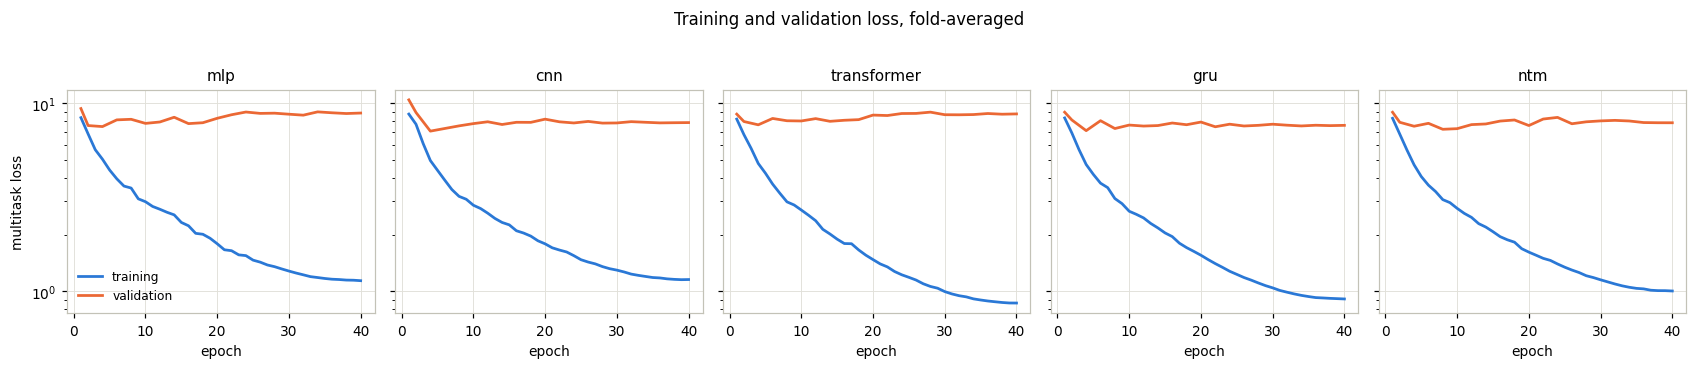

In [ ]:
figure, axes = plt.subplots(1, len(ORDER), figsize=(3.1 * len(ORDER), 3.2),
                            sharey=True)
for axis, encoder in zip(np.atleast_1d(axes), ORDER):
    length = min(len(c[0]) for c in curves[encoder])
    train = np.mean([c[0][:length] for c in curves[encoder]], axis=0)
    validation = np.mean([[v for _, v in c[1]] for c in curves[encoder]], axis=0)
    epochs = [e for e, _ in curves[encoder][0][1]]
    axis.plot(np.arange(1, length + 1), train, color=BLUE, lw=1.8,
              label="training")
    axis.plot(epochs, validation, color=ORANGE, lw=1.8, label="validation")
    axis.set_yscale("log")
    axis.set_xlabel("epoch")
    axis.set_title(encoder, fontsize=10)
np.atleast_1d(axes)[0].set_ylabel("multitask loss")
np.atleast_1d(axes)[0].legend(fontsize=8)
figure.suptitle("Training and validation loss, fold-averaged", y=1.03)
figure.tight_layout()
plt.show()

## 7. Actual vs predicted — defect x

Coloured by defect shape. Every point is out of fold.

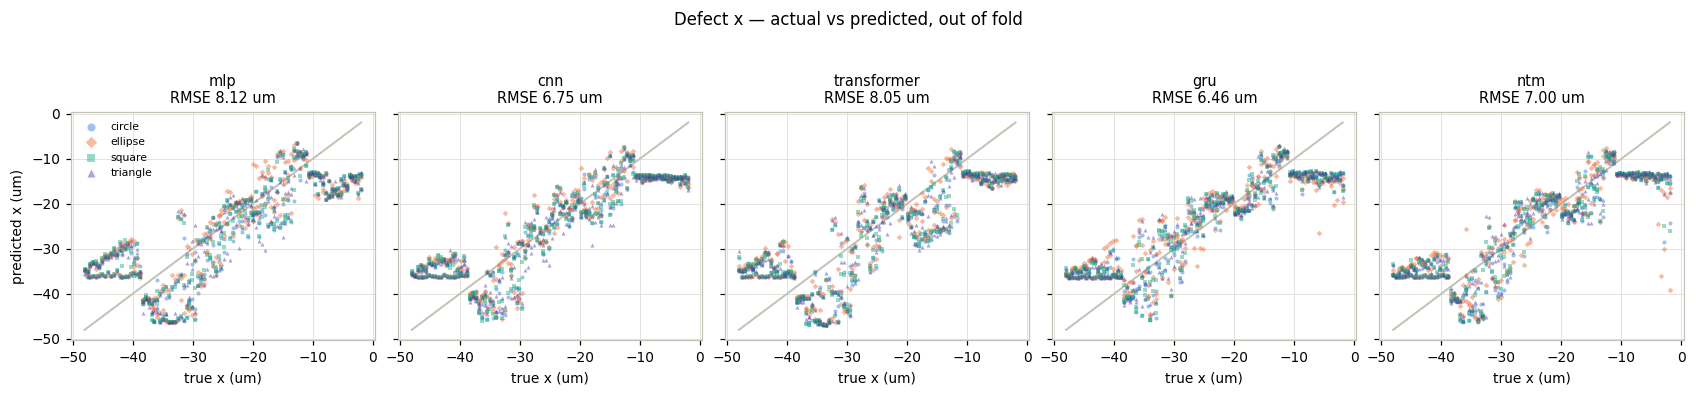

In [ ]:
figure, axes = plt.subplots(1, len(ORDER), figsize=(3.1 * len(ORDER), 3.4),
                            sharex=True, sharey=True)
labels = SHAPE_LABEL[X_ROWS]
for axis, encoder in zip(np.atleast_1d(axes), ORDER):
    predicted = results[encoder]["predictions"]["x"]
    axis.plot([x_x.min(), x_x.max()], [x_x.min(), x_x.max()],
              color="#c3c2b7", lw=1.3, zorder=1)
    for name in SHAPE_NAMES:
        mask = labels == name
        colour, marker = SHAPE_STYLE[name]
        axis.scatter(x_x[mask], predicted[mask], s=7, alpha=0.45, color=colour,
                     marker=marker, linewidths=0, label=name, zorder=2)
    rmse = np.sqrt(((predicted - x_x) ** 2).mean())
    axis.set_title(f"{encoder}\nRMSE {rmse:.2f} um", fontsize=9.5)
    axis.set_xlabel("true x (um)")
np.atleast_1d(axes)[0].set_ylabel("predicted x (um)")
np.atleast_1d(axes)[0].legend(fontsize=7, markerscale=2)
figure.suptitle("Defect x — actual vs predicted, out of fold", y=1.04)
figure.tight_layout()
plt.show()

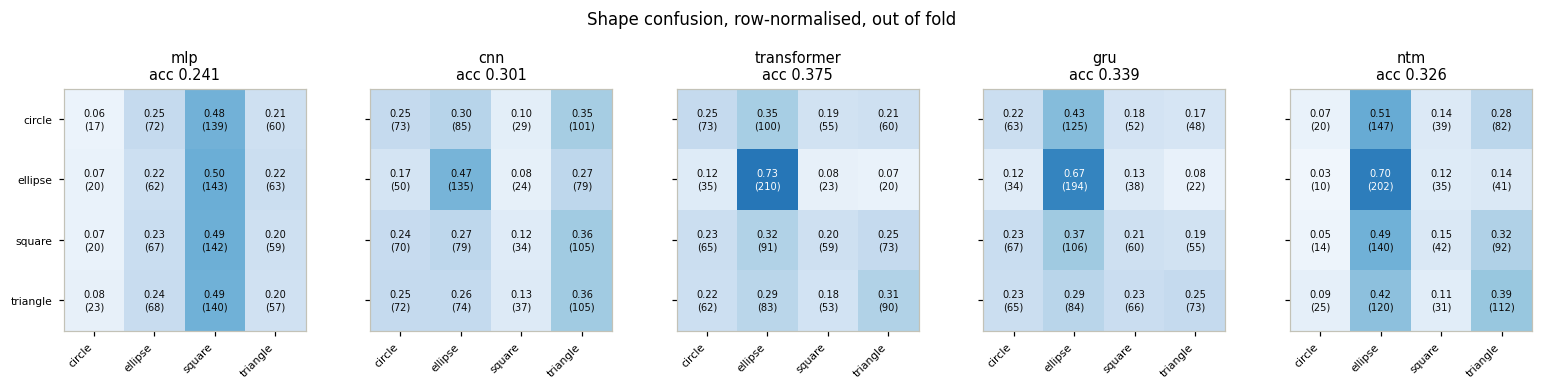

In [ ]:
n_shapes = len(SHAPE_NAMES)
figure, axes = plt.subplots(1, len(ORDER), figsize=(2.9 * len(ORDER), 3.1))
for axis, encoder in zip(np.atleast_1d(axes), ORDER):
    predicted = results[encoder]["predictions"]["shape"]
    matrix = np.zeros((n_shapes, n_shapes))
    for true, guess in zip(s_x, predicted):
        matrix[true, guess] += 1
    counts = matrix.copy()
    matrix = matrix / matrix.sum(1, keepdims=True).clip(min=1)
    axis.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    for i in range(n_shapes):
        for j in range(n_shapes):
            axis.text(j, i, f"{matrix[i, j]:.2f}\n({int(counts[i, j])})",
                      ha="center", va="center", fontsize=6.5, linespacing=1.3,
                      color="white" if matrix[i, j] > 0.55 else "#0b0b0b")
    axis.set_xticks(range(n_shapes))
    axis.set_xticklabels(SHAPE_NAMES, rotation=45, ha="right", fontsize=7)
    axis.set_yticks(range(n_shapes))
    axis.set_yticklabels(SHAPE_NAMES if axis is np.atleast_1d(axes)[0]
                         else [""] * n_shapes, fontsize=7)
    axis.grid(False)
    axis.set_title(f"{encoder}\nacc {(predicted == s_x).mean():.3f}",
                   fontsize=9.5)
figure.suptitle("Shape confusion, row-normalised, out of fold", y=1.05)
figure.tight_layout()
plt.show()

In [ ]:
Y_ROWS = np.flatnonzero(SOURCE == "y_sweep")
y_results = {}
if len(Y_ROWS):
    nf_y, ff_y = NF[Y_ROWS], FF[Y_ROWS]
    x_y, y_y, s_y = X_TRUE[Y_ROWS], Y_TRUE[Y_ROWS], SHAPE_ID[Y_ROWS]
    y_folds = grouped_sweep_folds(SWEEP_GROUP[Y_ROWS], CFG["y_folds"],
                                  stratify=SHAPE_LABEL[Y_ROWS])
    audit(y_folds, len(Y_ROWS))
    print(f"{CFG['y_folds']} grouped folds over {len(Y_ROWS)} y-sweep rows "
          f"({len(np.unique(SWEEP_GROUP[Y_ROWS]))} complete sweeps)\n")

    for encoder in ORDER:
        started = time.time()
        predicted_y = np.zeros(len(Y_ROWS))
        for fold in y_folds:
            predicted, *_ = train_one_fold(nf_y, ff_y, x_y, y_y, s_y, fold,
                                           encoder, CFG["y_epochs"],
                                           track_validation=False)
            predicted_y[fold["test"]] = predicted["y"]
        y_results[encoder] = predicted_y
        error = predicted_y - y_y
        print(f"  {encoder:12s} y MAE {np.abs(error).mean() * 1000:5.1f} nm   "
              f"RMSE {np.sqrt((error ** 2).mean()) * 1000:5.1f} nm   "
              f"[{(time.time() - started) / 60:.1f} min]", flush=True)

3 grouped folds over 2000 y-sweep rows (100 complete sweeps)

  mlp          y MAE 166.1 nm   RMSE 192.3 nm   [0.1 min]
  cnn          y MAE 154.6 nm   RMSE 179.8 nm   [0.1 min]
  transformer  y MAE 165.1 nm   RMSE 191.0 nm   [0.2 min]
  gru          y MAE 149.5 nm   RMSE 175.0 nm   [0.1 min]
  ntm          y MAE 155.2 nm   RMSE 181.4 nm   [1.8 min]


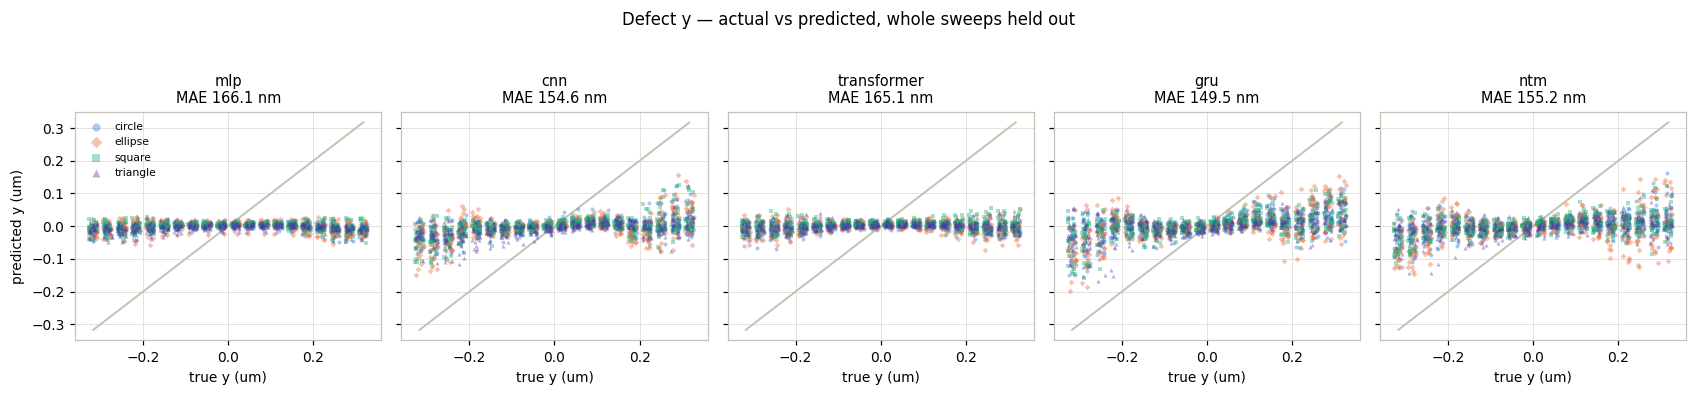

In [ ]:
if y_results:
    figure, axes = plt.subplots(1, len(ORDER), figsize=(3.1 * len(ORDER), 3.4),
                                sharex=True, sharey=True)
    labels_y = SHAPE_LABEL[Y_ROWS]
    generator = np.random.default_rng(0)
    spacing = np.diff(np.unique(y_y)).min()
    jitter = generator.uniform(-0.3 * spacing, 0.3 * spacing, len(y_y))
    for axis, encoder in zip(np.atleast_1d(axes), ORDER):
        predicted = y_results[encoder]
        axis.plot([y_y.min(), y_y.max()], [y_y.min(), y_y.max()],
                  color="#c3c2b7", lw=1.3, zorder=1)
        for name in SHAPE_NAMES:
            mask = labels_y == name
            colour, marker = SHAPE_STYLE[name]
            axis.scatter(y_y[mask] + jitter[mask], predicted[mask], s=7,
                         alpha=0.4, color=colour, marker=marker, linewidths=0,
                         label=name, zorder=2)
        mae = np.abs(predicted - y_y).mean()
        axis.set_title(f"{encoder}\nMAE {mae * 1000:.1f} nm", fontsize=9.5)
        axis.set_xlabel("true y (um)")
    np.atleast_1d(axes)[0].set_ylabel("predicted y (um)")
    np.atleast_1d(axes)[0].legend(fontsize=7, markerscale=2)
    figure.suptitle("Defect y — actual vs predicted, whole sweeps held out",
                    y=1.04)
    figure.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

table = []
for encoder in ORDER:
    predicted = results[encoder]["predictions"]
    error = predicted["x"] - x_x
    row = {
        "encoder": encoder,
        "params": f"{results[encoder]['parameters'] / 1e6:.2f} M",
        "x RMSE (um)": round(float(np.sqrt((error ** 2).mean())), 2),
        "x R2": round(float(1 - (error ** 2).sum()
                            / ((x_x - x_x.mean()) ** 2).sum()), 3),
        "shape acc": round(float((predicted["shape"] == s_x).mean()), 3),
        "min": round(results[encoder]["minutes"], 1),
    }
    if encoder in y_results:
        row["y MAE (nm)"] = round(
            float(np.abs(y_results[encoder] - y_y).mean() * 1000), 1)
    table.append(row)

summary = pd.DataFrame(table)
print(f"preset {PRESET}   {CFG['folds']} blocked folds   "
      f"{CFG['epochs']} epochs   chance on shape = {1 / n_shapes:.2f}\n")
print(summary.to_string(index=False))

preset fast   5 blocked folds   40 epochs   chance on shape = 0.25

    encoder params  x RMSE (um)  x R2  shape acc  min  y MAE (nm)
        mlp 3.21 M         8.12 0.635      0.241  0.2       166.1
        cnn 0.42 M         6.75 0.748      0.301  0.2       154.6
transformer 1.43 M         8.05 0.641      0.375  0.4       165.1
        gru 0.86 M         6.46 0.769      0.339  0.2       149.5
        ntm 0.58 M         7.00 0.728      0.326  2.6       155.2
